## Importing the libraries

# Support Vector Regression (SVR)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [3]:
print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [4]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


## Reshape Y into 2D array as X is in 2D Array form

In [3]:
y = y.reshape(len(y),1)

In [6]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


## Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler 
ac_x = StandardScaler()
ac_y = StandardScaler()
X = ac_x.fit_transform(X)
y = ac_y.fit_transform(y)

In [8]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [9]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


## Training the SVR model on the whole dataset

In [5]:
from sklearn.svm import SVR 
regressor = SVR(kernel='rbf')
regressor.fit(X,y)

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Predicting a new result

In [6]:
ac_y.inverse_transform( regressor.predict(ac_x.transform([[6.5]])).reshape(-1,1))
"""
in this ,
1.ac_x.transform([[6.5]]) :-scales the new input 6.5 using the same scaler
2.regressor.predict(...) :-send scaled value to SVR model which return prediction in scaled format
3..reshape(-1,1) :-  a common trick in NumPy to convert a 1D array to 2D
4.ac_y.inverse_transform(...) :- converts the predicted scaled value back to the original scale
 """

'\nin this ,\n1.ac_x.transform([[6.5]]) :-scales the new input 6.5 using the same scaler\n2.regressor.predict(...) :-send scaled value to SVR model which return prediction in scaled format\n3..reshape(-1,1) :-  a common trick in NumPy to convert a 1D array to 2D\n4.ac_y.inverse_transform(...) :- converts the predicted scaled value back to the original scale\n '

## Visualising the SVR results

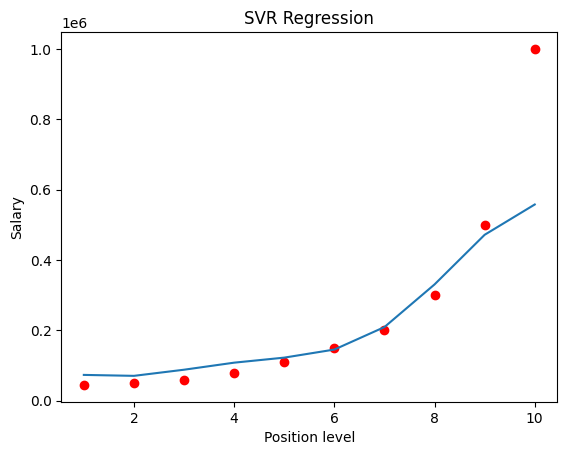

In [7]:
plt.scatter(ac_x.inverse_transform(X),ac_y.inverse_transform(y),color='red')
plt.plot(ac_x.inverse_transform(X),ac_y.inverse_transform( regressor.predict(X).reshape(-1,1)))
plt.title("SVR Regression")
plt.xlabel("Position level")
plt.ylabel("Salary")
plt.show()

## Visualising the SVR results (for higher resolution and smoother curve)

C:\Users\Hp\AppData\Local\Temp\ipykernel_1384\1485259851.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(ac_x.inverse_transform(X)), max(ac_x.inverse_transform(X)), 0.1)


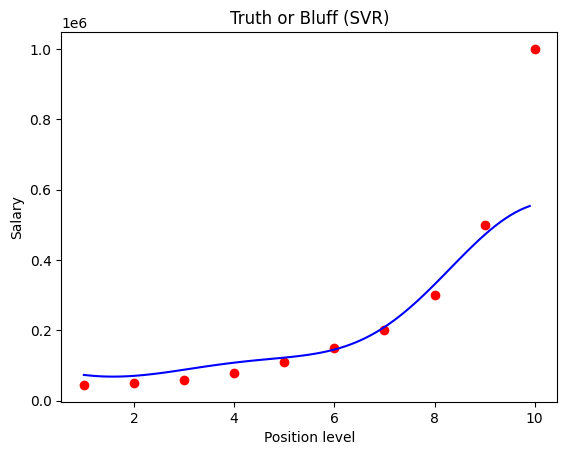

In [16]:
X_grid = np.arange(min(ac_x.inverse_transform(X)), max(ac_x.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(ac_x.inverse_transform(X), ac_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, ac_y.inverse_transform(regressor.predict(ac_x.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## Evaluating Model Performance

In [13]:
from sklearn.metrics import r2_score

# Predict using scaled X and inverse-transform the prediction using ac_y
y_pred = ac_y.inverse_transform(regressor.predict(X).reshape(-1, 1))

# Inverse-transform actual y values using ac_y
y_true = ac_y.inverse_transform(y)

# Compute R² score
r2 = r2_score(y_true, y_pred)
print("R-squared:", r2)


R-squared: 0.7516001070620798
